#Actividad 2
* Danna Pauleth López Acosta

In [ ]:
!pip install statsmodels

In [ ]:
!pip install wquantiles

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/titanic-train.csv')

In [ ]:
# Número total de registros en el dataset
total_pasajeros = df.shape[0]

# Sobrevivientes y no sobrevivientes
sobrevivientes = df['Survived'].sum()
no_sobrevivientes = total_pasajeros - sobrevivientes

# Tasa global de supervivencia
tasa_supervivencia = sobrevivientes / total_pasajeros

print(f"Total de pasajeros con información: {total_pasajeros}")
print(f"Sobrevivieron: {sobrevivientes}")
print(f"No sobrevivieron: {no_sobrevivientes}")
print(f"Tasa global de supervivencia: {tasa_supervivencia:.2%}")


Total de pasajeros con información: 891
Sobrevivieron: 342
No sobrevivieron: 549
Tasa global de supervivencia: 38.38%


<ipython-input-14-9464ada61f9b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette=['lightcoral', 'lightgreen'])


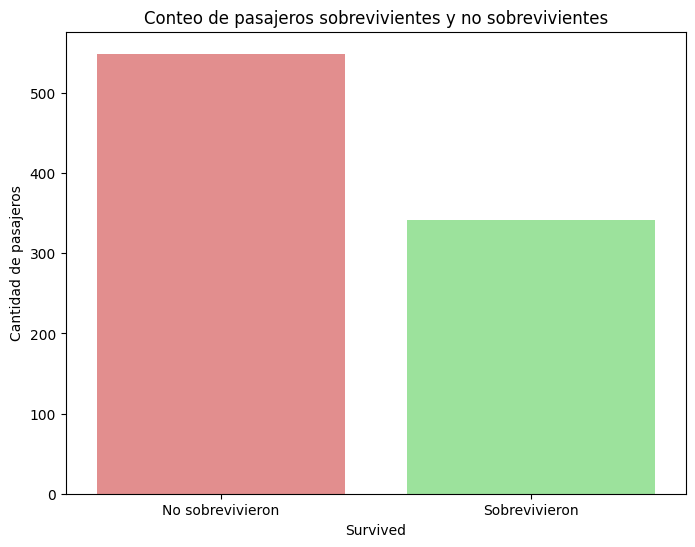

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data=df, palette=['lightcoral', 'lightgreen'])
plt.xticks([0,1], ['No sobrevivieron', 'Sobrevivieron'])
plt.ylabel('Cantidad de pasajeros')
plt.title('Conteo de pasajeros sobrevivientes y no sobrevivientes')
plt.show()



1. Los pasajeros con información fueron 891, de los cuales **sobrevivieron 342** y **fallecieron 549**, lo que siginica que solo **el 38% de los pasajeros sobrevivió**. Esto se puede demostrar en la grafica anterior.

In [ ]:
  # Conteo total de hombres y mujeres
conteo_sexo = df['Sex'].value_counts()
print(conteo_sexo)


Sex
male      577
female    314
Name: count, dtype: int64


In [ ]:
sexo_por_clase = pd.crosstab(df['Pclass'], df['Sex'])
print(sexo_por_clase)


Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


<ipython-input-26-d406be0e496b>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_sexo.index, y=conteo_sexo.values, palette=['lightcoral', 'lightgreen'])


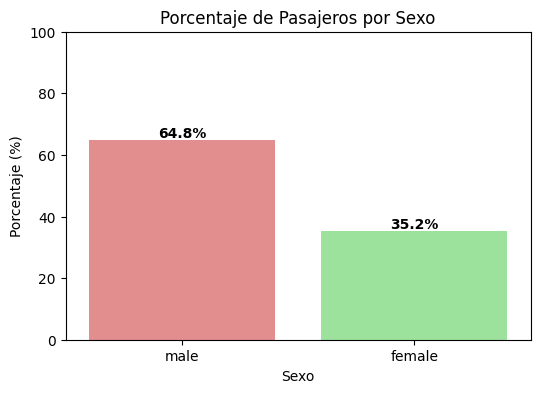

In [ ]:
# Calcular porcentajes
conteo_sexo = df['Sex'].value_counts(normalize=True) * 100
print(conteo_sexo)

# Graficar
plt.figure(figsize=(6,4))
ax = sns.barplot(x=conteo_sexo.index, y=conteo_sexo.values, palette=['lightcoral', 'lightgreen'])

# Etiquetas de porcentaje encima de cada barra
for i, v in enumerate(conteo_sexo.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Porcentaje de Pasajeros por Sexo')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Sexo')
plt.ylim(0, 100)
plt.show()


2. De los pasajeros del Titanic **577 eran hombres** y **314 mujeres**. Esto se puede demostrar en la grafica anterior, donde se muestra que **el 64.8% eran hombres** y **el 35.2 eran mujeres**.

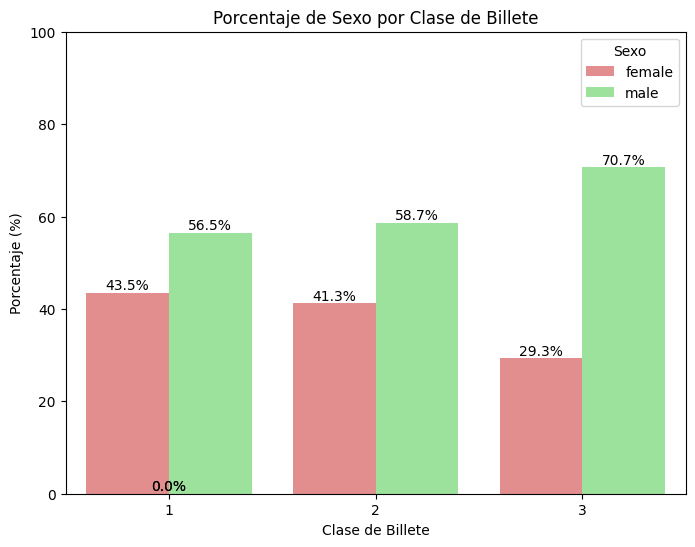

In [ ]:
# Calcular tabla de porcentaje por clase y sexo
sexo_por_clase = pd.crosstab(df['Pclass'], df['Sex'], normalize='index') * 100

# Rearmar formato para graficar fácilmente
sexo_por_clase = sexo_por_clase.reset_index().melt(id_vars='Pclass', var_name='Sex', value_name='Percentage')

# Graficar
plt.figure(figsize=(8,6))
ax = sns.barplot(x='Pclass', y='Percentage', hue='Sex', data=sexo_por_clase, palette=['lightcoral', 'lightgreen'])

# Etiquetas encima de las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Porcentaje de Sexo por Clase de Billete')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Clase de Billete')
plt.ylim(0, 100)
plt.legend(title='Sexo')
plt.show()


Según la grafica podemos observar que:

* En Primera Clase, la proporción entre hombres y mujeres estaba más equilibrada: con un 56.5% hombres y 43.5% mujeres.

* En Segunda Clase, también había más hombres, pero las mujeres representaban cerca del 42%.

* En Tercera Clase, la diferencia era aún mayor, con aproximadamente 71% de hombres y el resto son mujeres.

In [ ]:
# Número de hombres y mujeres que sobrevivieron
sobrevivientes_sexo = df[df['Survived'] == 1]['Sex'].value_counts()

print(sobrevivientes_sexo)


Sex
female    233
male      109
Name: count, dtype: int64


In [ ]:
# Tasa de supervivencia por sexo
supervivencia_sexo = df.groupby('Sex')['Survived'].mean() * 100

print(supervivencia_sexo)


Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [ ]:
# Tasa de supervivencia por clase de billete
supervivencia_clase = df.groupby('Pclass')['Survived'].mean() * 100

print(supervivencia_clase)


Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


<ipython-input-32-cd37cd38198c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=supervivencia_sexo.index, y=supervivencia_sexo.values, palette=['lightcoral', 'lightgreen'])


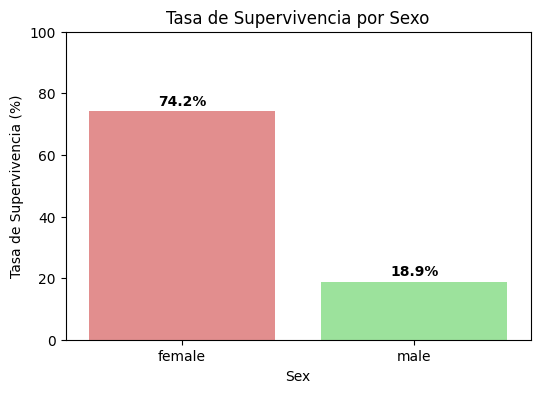

In [ ]:
# Gráfico de tasa de supervivencia por sexo
plt.figure(figsize=(6,4))
ax = sns.barplot(x=supervivencia_sexo.index, y=supervivencia_sexo.values, palette=['lightcoral', 'lightgreen'])

for i, v in enumerate(supervivencia_sexo.values):
    ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Tasa de Supervivencia por Sexo')
plt.ylabel('Tasa de Supervivencia (%)')
plt.ylim(0, 100)
plt.show()


Por la grafica se puede deducir, que era mucho más probable sobrevivir si se era mujer con un 74.2%, que siendo hombre con un 18.9%. Sobrevivieron 233 mujeres y 109 hombres.

In [ ]:
def extract_title(data):
  title=data["Name"].str.extract('([A-Za-z]+)\.',expand=True)
  return title

In [ ]:
df["Title"]=extract_title(df)

In [ ]:
df["Title"]=extract_title(df)

In [ ]:
def replace_titles(data):
    title_mapping = {"Mr": 0, "Miss": 1, "Mrs":2}
    data["Title"] =data["Title"].map(title_mapping).fillna(3)
    return data

In [ ]:
df=replace_titles(df)
df[["Name","Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",0.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2.0
2,"Heikkinen, Miss. Laina",1.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2.0
4,"Allen, Mr. William Henry",0.0


In [ ]:
title_age_means=df.groupby("Title")["Age"].mean()
title_age_means

,Age
Title,
0.0,32.368090
1.0,21.773973
2.0,35.898148
3.0,19.805473


In [ ]:
df["Age"]=df.apply(lambda x: title_age_means[x["Title"]] if pd.isnull(x["Age"]) else x["Age"],axis=1)

In [ ]:
df[["Title","Age"]].head()

,Title,Age
0,0.0,22.0
1,2.0,38.0
2,1.0,26.0
3,2.0,35.0
4,0.0,35.0


* Niño: 0
* Joven: 1
* Adulto: 2
* Edad madura: 3
* Edad avanzada: 4

In [ ]:
df["Age_Category"]=pd.cut(df["Age"],bins=[0,16,26,36,62,float("inf")],labels=[0,1,2,3,4],right=False)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Category,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,2,0.0


In [ ]:
# Número total de registros en el dataset
total_pasajeros = df.shape[0]

# Sobrevivientes y no sobrevivientes
Pasajeros_con_edad = df['Age'].sum()
Pasajeros_sin_edad = total_pasajeros - Pasajeros_con_edad

print(f"Total de pasajeros con información: {total_pasajeros}")
print(f"Pasajeron con edad: {Pasajeros_con_edad}")
print(f"Pasajeros sin edad: {Pasajeros_sin_edad}")

Total de pasajeros con información: 891
Pasajeron con edad: 26511.400962702908
Pasajeros sin edad: -25620.400962702908
